In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading California Housing dataset

housing = fetch_california_housing()

# Creating DataFrame

df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Adding target column

df['Price'] = housing.target

# Display first 5 rows

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset Information

# This section shows:
# - Number of rows and columns
# - Data types
# - Dataset structure
# Shape of dataset

print("Dataset Shape:", df.shape)

# Dataset information

df.info()

Dataset Shape: (20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Checking missing values

df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [5]:
# Statistical summary of dataset

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


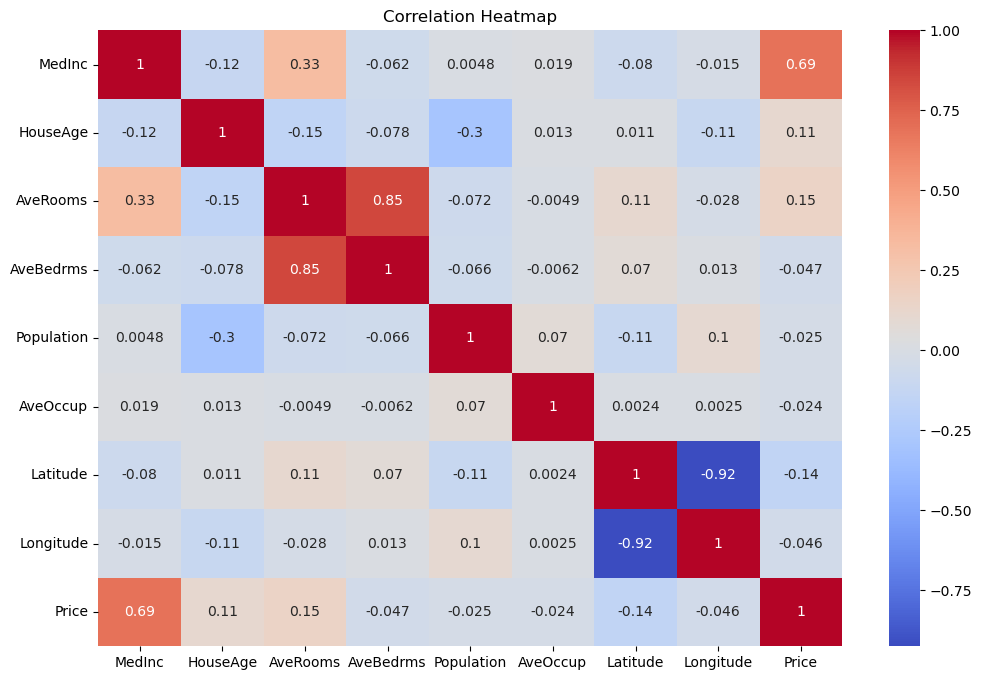

In [6]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

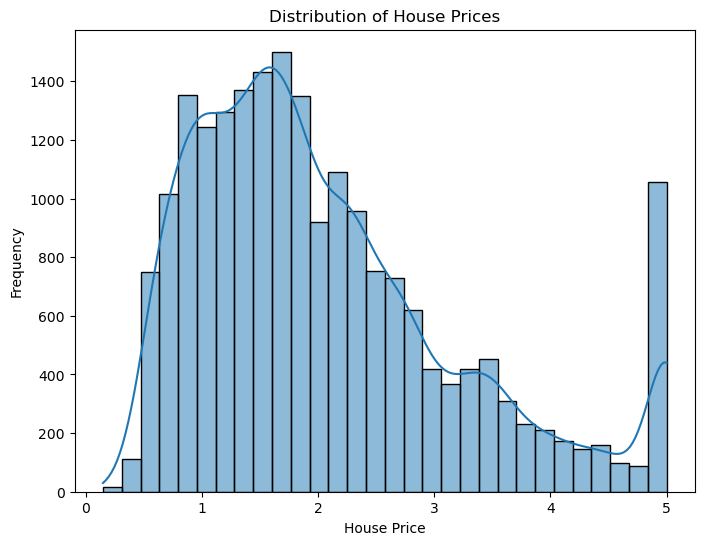

In [7]:
# Distribution of house prices

plt.figure(figsize=(8,6))

sns.histplot(df['Price'], bins=30, kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("House Price")

plt.ylabel("Frequency")

plt.show()

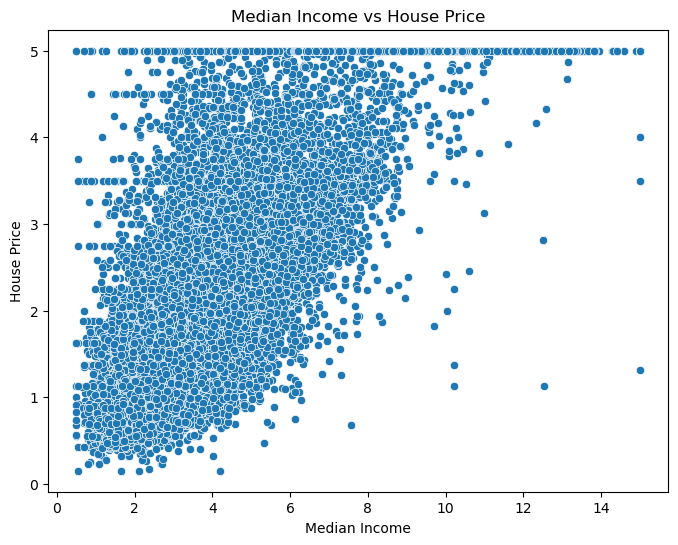

In [8]:
# Scatter plot between Median Income and House Price

plt.figure(figsize=(8,6))

sns.scatterplot(x=df['MedInc'], y=df['Price'])

plt.title("Median Income vs House Price")

plt.xlabel("Median Income")

plt.ylabel("House Price")

plt.show()

In [12]:
#Feature Selection and Data Splitting
# Independent variables

X = df.drop('Price', axis=1)

# Dependent variable

y = df['Price']

In [13]:
# Splitting dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


In [14]:
# Creating Linear Regression model

model = LinearRegression()

# Training model

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [15]:
# Predicting house prices

y_pred = model.predict(X_test)

# Displaying predicted values

print(y_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


In [16]:
# Mean Absolute Error

mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error

mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error

rmse = np.sqrt(mse)

# R2 Score

r2 = r2_score(y_test, y_pred)

# Printing evaluation metrics

print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956546
Mean Squared Error (MSE): 0.5558915986952444
Root Mean Squared Error (RMSE): 0.7455813830127764
R2 Score: 0.5757877060324508


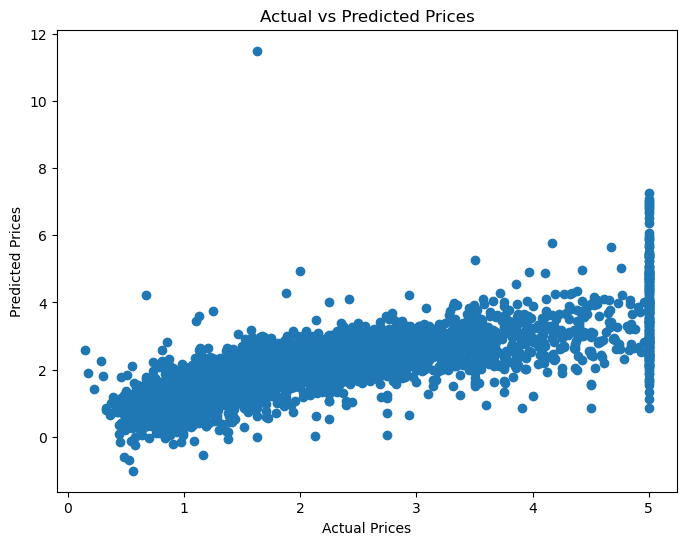

In [17]:
# Scatter plot for actual vs predicted values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

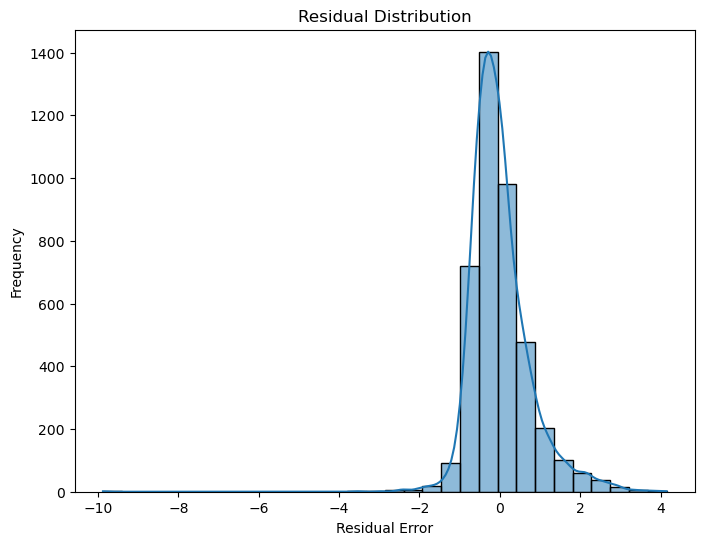

In [18]:
#Residual plot
# Calculating residuals

residuals = y_test - y_pred

# Plotting residual distribution

plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.show()

In [19]:
# Displaying feature coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [20]:
# Save model
# Importing pickle

import pickle

# Saving trained model

with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully
